In [1]:
from gould_2026.estimator import Pipeline, ArrayWithTime, CenteringEstimator
from gould_2026.dimension_reduction.prosvd import proSVD
from gould_2026.prediction.kalman_filter import StreamingKalmanFilter
from gould_2026.stim_regressor import StimRegressor, StimAutoReg
from gould_2026.datasets import Naumann24uDataset
import numpy as np
import matplotlib.pyplot as plt


In [49]:
output1 = None
output2 = None
output3 = None
output4 = None
output5 = None

In [2]:
rng = np.random.default_rng()
d = Naumann24uDataset(1)

target_neurons = np.unique(d.opto_stimulations.target_neuron)

d.neural_data[np.isnan(d.neural_data)] = 0

def target_neuron_to_vector(tn):
    v = target_neurons * 0
    v[target_neurons == tn] = 1
    return v

d.opto_stimulations['stim_vector'] = d.opto_stimulations['target_neuron'].apply(target_neuron_to_vector)




/home/jgould/Documents/2026_paper/gould_2026/datasets.py:637: UserWarning: bin width is actually improper here
  warnings.warn("bin width is actually improper here")


In [3]:
p = Pipeline([
    CenteringEstimator(init_size=100, nan_when_uninitialized=True),
    proSVD(k=10),
])


latents = p.offline_run_on(d.neural_data, show_tqdm=True)
stim = ArrayWithTime(np.squeeze([x for x  in d.opto_stimulations['stim_vector']]), d.opto_stimulations['time'])


  0%|          | 0/1824.27 [00:00<?, ?it/s]

/home/jgould/Documents/2026_paper/gould_2026/estimator.py:743: UserWarning: time steps for training are not consistent
  warnings.warn('time steps for training are not consistent')


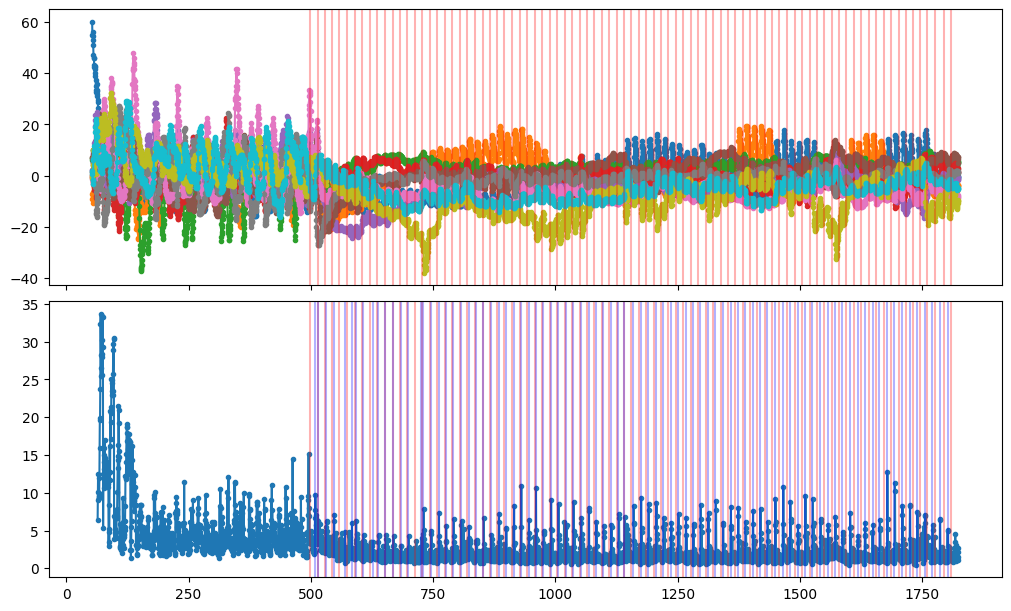

In [4]:
%matplotlib inline

fig, axs = plt.subplots(nrows=2, figsize=(10,6), layout='constrained', sharex=True)
axs[0].plot(latents.t, latents, '.-')


kf = StreamingKalmanFilter(log_level=2, check_dt=True)
kf.offline_run_on(latents)
errors = ArrayWithTime.from_list(kf.log['pred_error'], squeeze_type='to_2d')
errors  = ArrayWithTime(np.linalg.norm(errors, axis=1), errors.t)
axs[1].plot(errors.t, errors, '.-')

stim_ts = []
for t1, t2 in zip(stim.t, stim.t[1:]):
    s = errors.slice_by_time(slice(t1, t2))
    stim_t = s.t[np.argmax(s)]
    stim_ts.append(max(stim_t - 2 * latents.dt, t1))

for t in stim.t:
    axs[0].axvline(t, color='red', alpha=0.3)
    axs[1].axvline(t, color='red', alpha=0.3)

for t in stim_ts:
    # axs[0].axvline(t, color='blue', alpha=0.3)
    axs[1].axvline(t, color='blue', alpha=0.3)

stim_shifted = ArrayWithTime(stim[:-1], np.array(stim_ts))

In [5]:
srs = {
    'blind': StimRegressor(log_level=2, heed_stimuli=False, attempt_correction=False),
    'reg': StimRegressor(log_level=2, stim_delay=1*latents.dt),
}
srs['reg'].stim_autoreg = StimAutoReg(n_steps_to_consider=4)

for sr in srs.values():
    sr.offline_run_on([(stim_shifted, 'stim'), (latents, 'X')], show_tqdm=True)

  0%|          | 0/1802.32 [00:00<?, ?it/s]

/home/jgould/Documents/2026_paper/gould_2026/estimator.py:482: UserWarning: No outputs were routed to stream '0'.
  warnings.warn(f"No outputs were routed to stream '{convinient_return}'.")


  0%|          | 0/1802.32 [00:00<?, ?it/s]

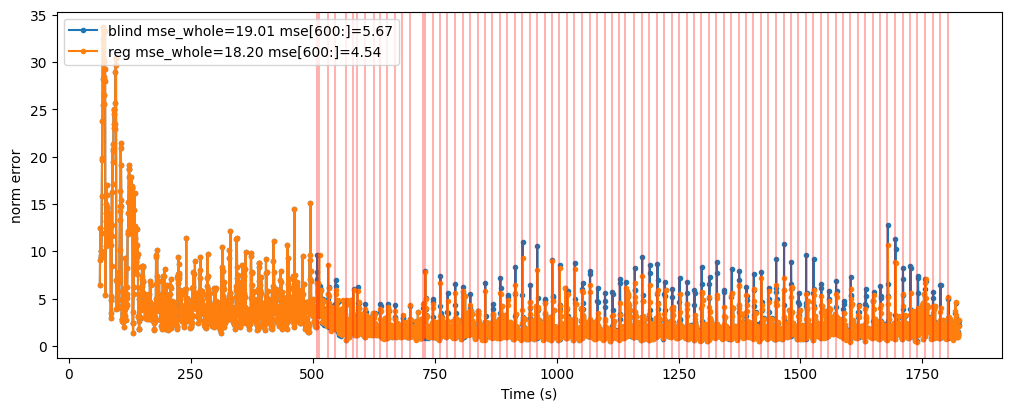

In [6]:
%matplotlib inline
fig, ax = plt.subplots(constrained_layout=True, figsize=(10,4))

for k, sr in srs.items():
    error = ArrayWithTime.from_list(sr.log['pred_error'], squeeze_type='to_2d')
    norm_error = ArrayWithTime(np.linalg.norm(error, axis=1),error.t)
    ax.plot(norm_error.t, norm_error, '.-', label=f'{k} mse_whole={np.nanmean(norm_error ** 2):.2f} mse[600:]={np.nanmean(norm_error.slice_by_time(slice(600,None))** 2):.2f}')

ax.legend()
# ax.set_xlim([700, 1300])
# ax.set_ylim([0,12])

ax.set_xlabel('Time (s)')
ax.set_ylabel('norm error')

for t in stim_shifted.t:
    ax.axvline(t, color='red', alpha=0.3)

if output1 is not None:
    fig.savefig(output1)


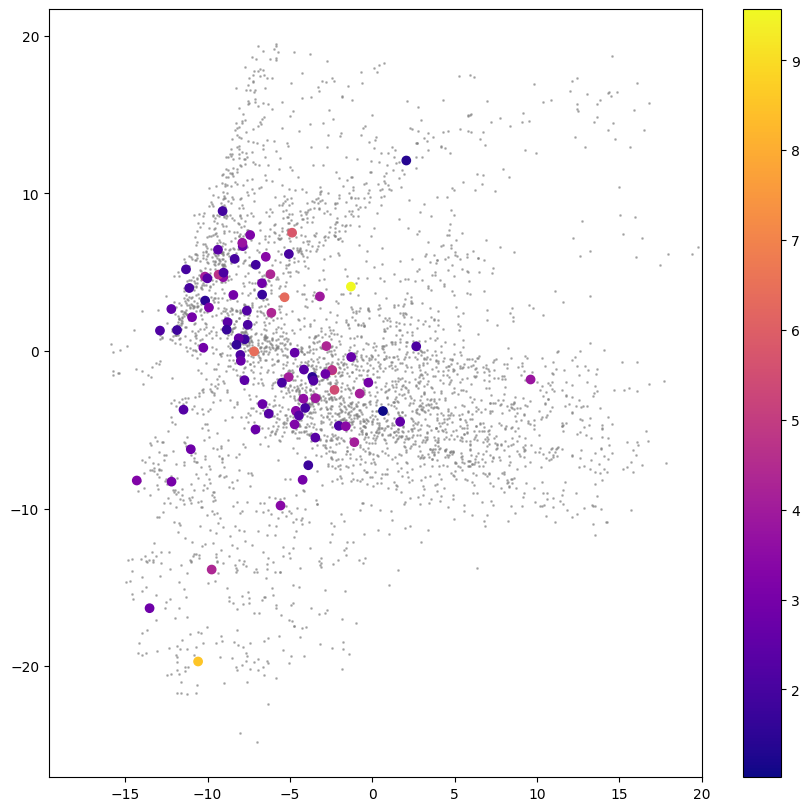

In [7]:
kf_error = ArrayWithTime.from_list(srs['reg'].log['pred_error'])

fig, ax = plt.subplots(constrained_layout=True, figsize=(8,8))

preq_errors = ArrayWithTime.from_list(srs['reg'].stim_reg.log['preq_errors'], squeeze_type='to_2d')
preq_errors = np.linalg.norm(preq_errors,axis=1)
n_observed = srs['reg'].stim_reg.n_observed


ax.scatter(latents[:,0], latents[:,1], c='gray', alpha=0.5, s=1)
error_scatter = ax.scatter(srs['reg'].stim_reg.input_histories[0][:n_observed,0], srs['reg'].stim_reg.input_histories[0][:n_observed,1], c=preq_errors, cmap='plasma')
ax.set_xlim(right=20)
fig.colorbar(error_scatter)


if output2 is not None:
    fig.savefig(output2)



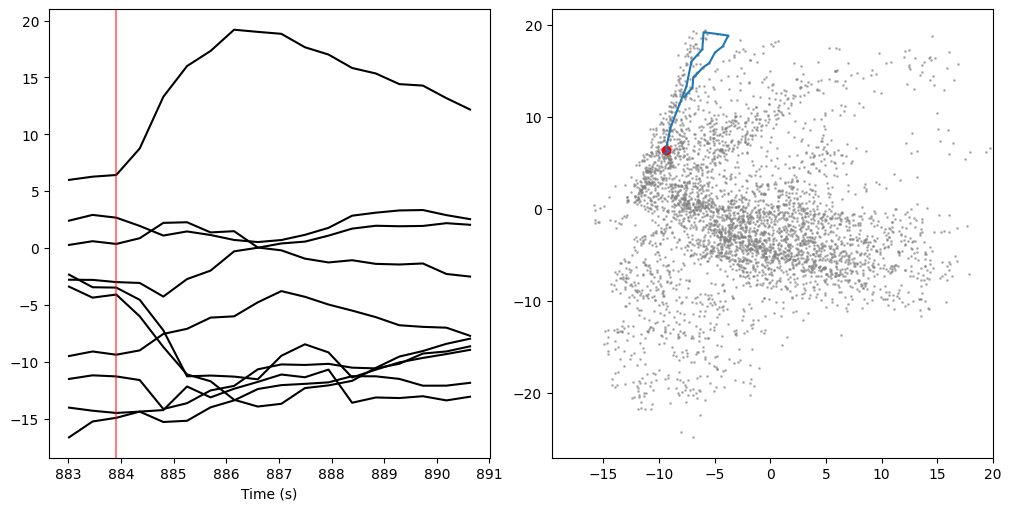

In [8]:
%matplotlib inline
fig, axs = plt.subplots(constrained_layout=True, figsize=(10,5), ncols=2)

n = 25
l = 1
r = 7
time_slice = slice(stim_shifted.t[n] -l, stim_shifted.t[n] + r)

ax = axs[1]
ax.scatter(latents[:,0], latents[:,1], c='gray', alpha=0.5, s=1)
# ax.plot(latents[:,0], latents[:,1], '-')
ax.set_xlim(right=20)
idx = np.argmin(np.linalg.norm(latents - srs['reg'].stim_reg.input_histories[0][0],axis=1))
assert np.linalg.norm(latents.slice(idx) - srs['reg'].stim_reg.input_histories[0][0]) < 1e-10
idx = latents.time_to_sample(srs['reg'].stim_reg.input_histories[2][:n_observed, 0]) -1
latents_at_stims = latents.slice(idx).slice_by_time(time_slice)
ax.scatter(latents_at_stims[:,0], latents_at_stims[:,1], c='r')
latent_slice = latents.slice_by_time(time_slice)
ax.plot(latent_slice[:,0], latent_slice[:,1])

ax = axs[0]
# full_slice = d.neural_data.slice_by_time(time_slice)
# ax.plot(full_slice.t, full_slice, 'k');
ax.plot(latent_slice.t, latent_slice, 'k');
for t in latents_at_stims.t:
    ax.axvline(t, color='r', alpha=0.5)
ax.set_xlabel('Time (s)')


if output3 is not None:
    fig.savefig(output3)



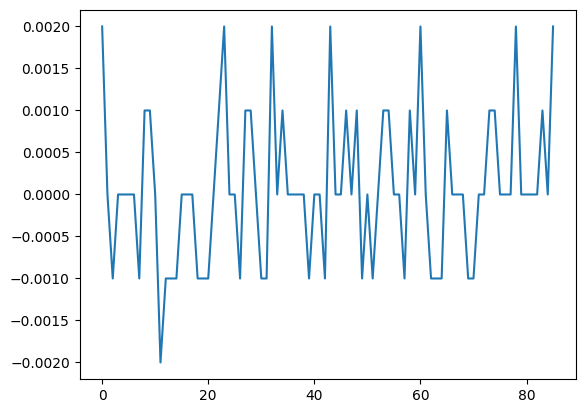

In [9]:
plt.plot(stim_shifted.t + latents.dt - srs['reg'].stim_reg.input_histories[2][:n_observed, 0])
# TODO: resolve this!!

In [10]:
d = Naumann24uDataset(1)

target_neurons = np.unique(d.opto_stimulations.target_neuron)

d.neural_data[np.isnan(d.neural_data)] = 0


def target_neuron_to_vector(tn):
    v = target_neurons * 0
    v[target_neurons == tn] = 1
    return v


d.opto_stimulations['stim_vector'] = d.opto_stimulations['target_neuron'].apply(target_neuron_to_vector)

p = Pipeline([
    CenteringEstimator(init_size=100, nan_when_uninitialized=True),
    proSVD(k=10),
])

latents = p.offline_run_on(d.neural_data, show_tqdm=True)
stim = ArrayWithTime(np.squeeze([x for x in d.opto_stimulations['stim_vector']]), d.opto_stimulations['time'])


/home/jgould/Documents/2026_paper/gould_2026/datasets.py:637: UserWarning: bin width is actually improper here
  warnings.warn("bin width is actually improper here")


  0%|          | 0/1824.27 [00:00<?, ?it/s]

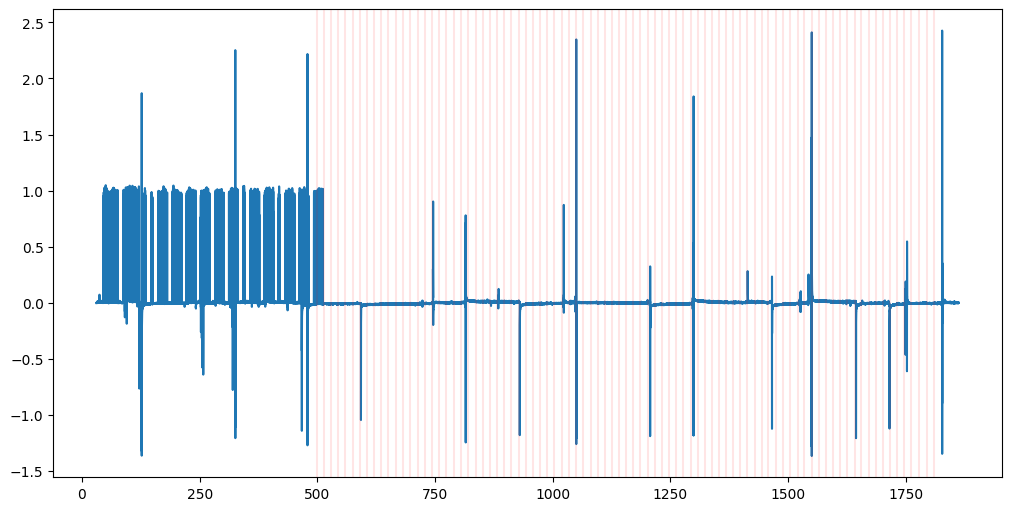

In [11]:

beh = d.behavioral_data
fig, ax = plt.subplots(constrained_layout=True, figsize=(10,5))
ax.plot(beh.t, beh)

for t in d.opto_stimulations.time:
    ax.axvline(t, color='red', alpha=0.1)


if output4 is not None:
    fig.savefig(output4)

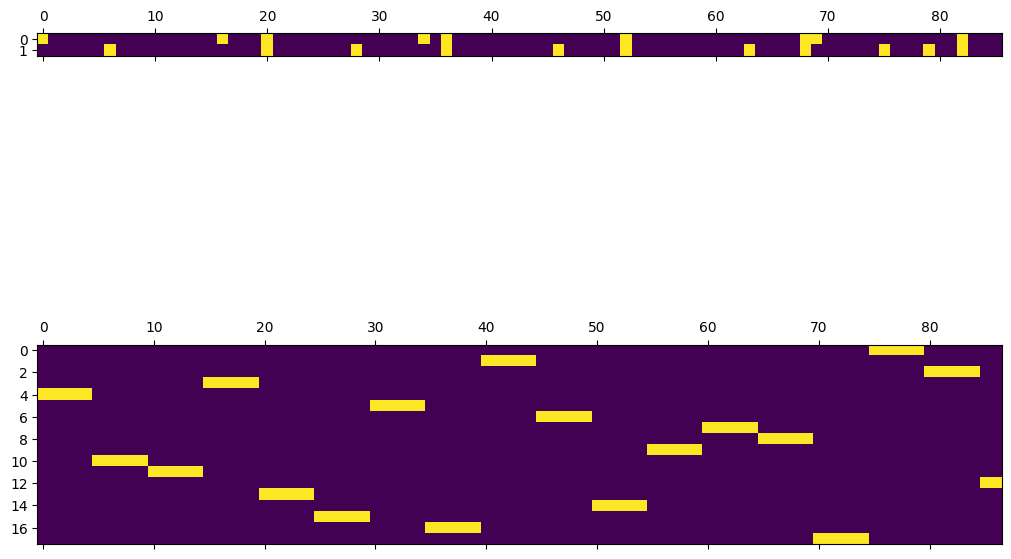

In [12]:

b2 = []
for a,b in zip(d.opto_stimulations.time, d.opto_stimulations.time[1:]):
    s = slice(a,b)
    b = beh.slice_by_time(s)
    b2.append(ArrayWithTime([b.max() > .5, b.min() < -.5], a + .1))

b2 = ArrayWithTime.from_list(b2, squeeze_type='to_2d')

fig, axs = plt.subplots(constrained_layout=True, nrows=2, figsize=(10,8), height_ratios=[1,10])
axs[0].matshow(b2.T)
axs[1].matshow(stim.T)


  0%|          | 0/85 [00:00<?, ?it/s]

/home/jgould/Documents/2026_paper/gould_2026/prediction/kalman_filter.py:240: UserWarning: covariance matrix is not positive definite
  warnings.warn("covariance matrix is not positive definite")
/home/jgould/Documents/2026_paper/gould_2026/estimator.py:482: UserWarning: No outputs were routed to stream '0'.
  warnings.warn(f"No outputs were routed to stream '{convinient_return}'.")


  0%|          | 0/85 [00:00<?, ?it/s]

0.22459728489772993
0.3064210125897873


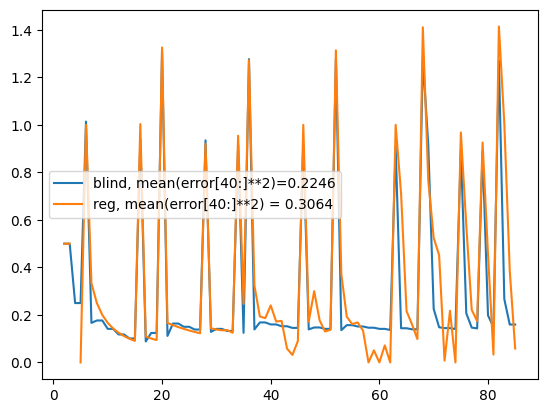

In [13]:
%matplotlib inline

sr1 = StimRegressor(log_level=2, autoreg=StreamingKalmanFilter(steps_between_refits=2), heed_stimuli=False, attempt_correction=False)
sr2 = StimRegressor(log_level=2, autoreg=StreamingKalmanFilter(steps_between_refits=2))

sr1.offline_run_on([(ArrayWithTime.from_notime(stim).slice(slice(4,None)), 'stim'), (ArrayWithTime.from_notime(b2), 'X')], show_tqdm=True)
sr2.offline_run_on([(ArrayWithTime.from_notime(stim).slice(slice(4,None)), 'stim'), (ArrayWithTime.from_notime(b2), 'X')], show_tqdm=True)

error = ArrayWithTime.from_list(sr1.log['pred_error'], squeeze_type='to_2d')
ne = np.linalg.norm(error, axis=1)
print(me1 :=np.nanmean(ne[40:]**2))
plt.plot(error.t, ne)

error = ArrayWithTime.from_list(sr2.log['pred_error'], squeeze_type='to_2d')
ne = np.linalg.norm(error, axis=1)
print(me2:=np.nanmean(ne[40:]**2))
plt.plot(error.t, ne)


plt.legend([f'blind, mean(error[40:]**2)={me1:.4f}', f'reg, mean(error[40:]**2) = {me2:.4f}'])



In [14]:
ne = ArrayWithTime(ne, stim.slice(slice(3,None)).t)

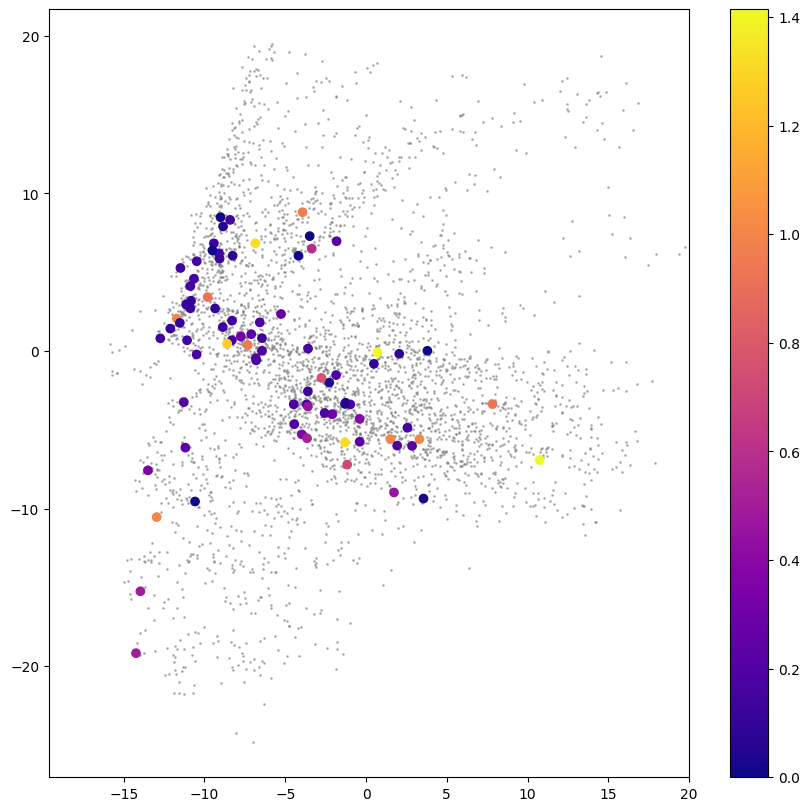

In [15]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(8,8))

# preq_errors = ArrayWithTime.from_list(srs['reg'].stim_reg.log['preq_errors'], squeeze_type='to_2d')
# preq_errors = np.linalg.norm(preq_errors,axis=1)
n_observed = srs['reg'].stim_reg.n_observed


ax.scatter(latents[:,0], latents[:,1], c='gray', alpha=0.5, s=1)

ls = np.array(latents.slice_by_time(ne.t))
error_scatter = ax.scatter(ls[:,0], ls[:,1], c=np.array(ne), cmap='plasma')
ax.set_xlim(right=20)
fig.colorbar(error_scatter)

if output5 is not None:
    fig.savefig(output5)
